# Single Asset Backtest with VectorBT

**Docker image**: `ml4t`

This notebook introduces **VectorBT** - a vectorized backtesting library that enables
fast simulation of trading strategies. We start with a simple single-asset RSI mean-reversion
strategy on Bitcoin before moving to multi-asset portfolio strategies.

**Learning Objectives:**
1. Understand VectorBT's core API and portfolio simulation
2. Implement entry/exit signals from technical indicators
3. Analyze performance metrics and visualizations
4. Compare strategy vs buy-and-hold benchmark

**Book Reference:** Chapter 16, Section 16.3 — vectorized and event-driven engines.

**Prerequisites:** Ch16 NB 01 (backtesting first principles).

**Strategy:** RSI Mean Reversion on BTC
- **Long Entry**: RSI < 30 (oversold)
- **Exit**: RSI > 70 (overbought)
- **Rebalancing**: Daily
- **Transaction Costs**: 10 bps

## Setup

In [1]:
"""Single Asset Backtest with VectorBT — RSI mean-reversion strategy using vectorized backtesting."""

import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import plotly.graph_objects as go
import polars as pl
import vectorbt as vbt
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from plotly.subplots import make_subplots

from data import load_crypto_perps

vbt.settings["plotting"]["use_widgets"] = False

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2020-01-01"
END_DATE = "2024-01-01"
INITIAL_CASH = 100_000

## 1. Data Acquisition

Load BTC/USDT daily bars from the local crypto perpetuals dataset and
convert to a pandas Series indexed by timestamp — VectorBT expects pandas.

In [3]:
_crypto = load_crypto_perps()
btc_df = (
    _crypto.filter(
        (pl.col("symbol") == "BTCUSDT")
        & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
        & (pl.col("timestamp") < pl.lit(END_DATE).str.to_datetime().dt.replace_time_zone("UTC"))
    )
    .sort("timestamp")
    .with_columns(pl.col("timestamp").dt.replace_time_zone(None))
    .group_by_dynamic("timestamp", every="1d")
    .agg(
        pl.col("open").first(),
        pl.col("high").max(),
        pl.col("low").min(),
        pl.col("close").last(),
        pl.col("volume").sum(),
    )
)

# Convert to pandas Series for VectorBT
btc_pd = btc_df.to_pandas()
btc_pd.set_index("timestamp", inplace=True)
close = btc_pd["close"]

print(f"Loaded {len(btc_df):,} daily bars for BTCUSDT from the crypto perpetuals dataset")
print(f"Date range: {btc_df['timestamp'].min()} to {btc_df['timestamp'].max()}")

Loaded 1,461 daily bars for BTCUSDT from the crypto perpetuals dataset
Date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00


In [4]:
# Preview the data
close.head(10)

timestamp
2020-01-01    7197.57
2020-01-02    6962.04
2020-01-03    7341.72
2020-01-04    7350.71
2020-01-05    7354.36
2020-01-06    7757.39
2020-01-07    8152.49
2020-01-08    8059.84
2020-01-09    7818.59
2020-01-10    8207.09
Name: close, dtype: float64

## 2. RSI Indicator Calculation

VectorBT provides optimized indicator calculations. The RSI indicator
can be computed for multiple parameter values simultaneously.

In [5]:
# Single RSI calculation with standard 14-day period
rsi = vbt.RSI.run(close, window=14)

In [6]:
# Preview RSI values
rsi_series = rsi.rsi
print("RSI Statistics:")
print(f"  Mean: {rsi_series.mean():.1f}")
print(f"  Std:  {rsi_series.std():.1f}")
print(f"  Min:  {rsi_series.min():.1f}")
print(f"  Max:  {rsi_series.max():.1f}")

RSI Statistics:
  Mean: 53.3
  Std:  17.8
  Min:  6.2
  Max:  99.4


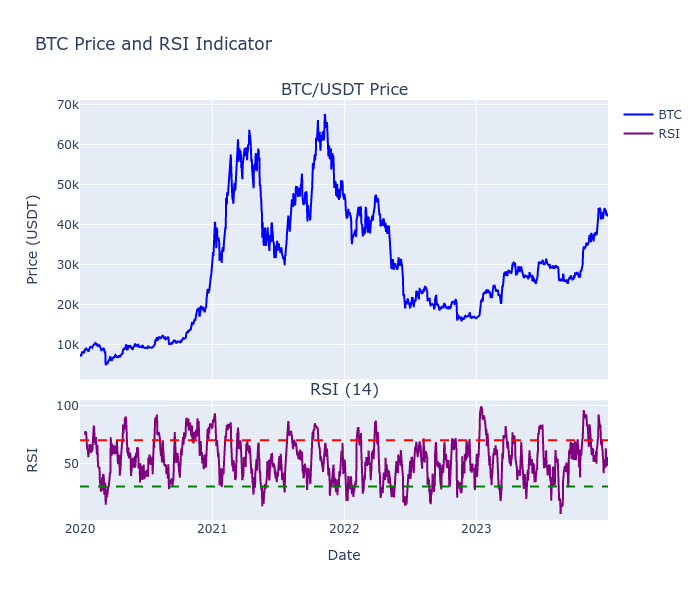

In [7]:
# Visualize price and RSI
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.7, 0.3],
    subplot_titles=["BTC/USDT Price", "RSI (14)"],
)

fig.add_trace(go.Scatter(x=close.index, y=close, name="BTC", line=dict(color="blue")), row=1, col=1)

fig.add_trace(
    go.Scatter(x=rsi_series.index, y=rsi_series, name="RSI", line=dict(color="purple")),
    row=2,
    col=1,
)

# Add RSI threshold lines
fig.add_hline(y=30, line_dash="dash", line_color="green", row=2, col=1)
fig.add_hline(y=70, line_dash="dash", line_color="red", row=2, col=1)

fig.update_layout(
    height=600,
    title="BTC Price and RSI Indicator",
    showlegend=True,
    xaxis2_title="Date",
    yaxis_title="Price (USDT)",
    yaxis2_title="RSI",
)
fig.show()

## 3. Generate Trading Signals

RSI Mean Reversion Logic:
- **Enter Long**: RSI falls below 30 (oversold → expect bounce)
- **Exit Long**: RSI rises above 70 (overbought → take profit)

In [8]:
# Define entry and exit signals
rsi_lower = 30  # Oversold threshold
rsi_upper = 70  # Overbought threshold

# Entry: RSI < lower threshold
entries = rsi_series < rsi_lower

# Exit: RSI > upper threshold
exits = rsi_series > rsi_upper

In [9]:
# Count signals
print(f"Entry signals: {entries.sum()}")
print(f"Exit signals: {exits.sum()}")

Entry signals: 146
Exit signals: 265


## 4. Run Backtest with VectorBT

VectorBT's `Portfolio.from_signals()` is the core backtesting function.
It simulates a portfolio based on entry/exit signals.

In [10]:
# Backtest cost parameters
FEES = 0.001  # 10 bps per trade
SLIPPAGE = 0.0005  # 5 bps slippage

In [11]:
# Run backtest
portfolio = vbt.Portfolio.from_signals(
    close=close,
    entries=entries,
    exits=exits,
    size=0.95,  # 95% of capital per trade
    size_type="percent",
    init_cash=INITIAL_CASH,
    fees=FEES,
    slippage=SLIPPAGE,
    freq="1D",
)

**Portfolio performance summary** (VectorBT's built-in stats):

In [12]:
portfolio.stats()

Start                         2020-01-01 00:00:00
End                           2023-12-31 00:00:00
Period                         1461 days 00:00:00
Start Value                              100000.0
End Value                            74616.213125
Total Return [%]                       -25.383787
Benchmark Return [%]                   487.892858
Max Gross Exposure [%]                  95.992895
Total Fees Paid                       2038.973418
Max Drawdown [%]                         65.84226
Max Drawdown Duration           967 days 00:00:00
Total Trades                                   14
Total Closed Trades                            14
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            57.142857
Best Trade [%]                          28.832715
Worst Trade [%]                        -43.724581
Avg Winning Trade [%]                   15.628523
Avg Losing Trade [%]                   -20.528611


The RSI mean-reversion strategy loses money on BTC — a strongly trending
asset over 2020–2023. This is expected: mean reversion buys dips that
continue falling and exits before the major rallies. The low Sharpe (< 0.1)
and negative expectancy confirm that simple mean reversion is a poor fit
for crypto's trending regime. This deliberately illustrates why strategy-data
fit matters more than indicator sophistication.

## 5. Analyze Trade Statistics

In [13]:
# Extract trade details
trades = portfolio.trades.records_readable
print(f"Total trades: {len(trades)}")

Total trades: 14


**Trade statistics** (per-trade entry/exit, P&L, holding period summary):

In [14]:
portfolio.trades.stats()

Start                         2020-01-01 00:00:00
End                           2023-12-31 00:00:00
Period                         1461 days 00:00:00
First Trade Start             2020-02-26 00:00:00
Last Trade End                2023-10-08 00:00:00
Coverage                        629 days 00:00:00
Overlap Coverage                  0 days 00:00:00
Total Records                                  14
Total Long Trades                              14
Total Short Trades                              0
Total Closed Trades                            14
Total Open Trades                               0
Open Trade PnL                                0.0
Win Rate [%]                            57.142857
Max Win Streak                                  4
Max Loss Streak                                 2
Best Trade [%]                          28.832715
Worst Trade [%]                        -43.724581
Avg Winning Trade [%]                   15.628523
Avg Losing Trade [%]                   -20.528611


**First 10 individual trades** with entry/exit timing and realized P&L:

In [15]:
display_cols = [
    "Entry Timestamp",
    "Exit Timestamp",
    "Size",
    "Entry Price",
    "Exit Price",
    "PnL",
    "Return",
]
available_cols = [c for c in display_cols if c in trades.columns]
trades[available_cols].head(10)

,Entry Timestamp,Exit Timestamp,Size,PnL,Return
0,2020-02-26,2020-03-26,10.788819,-22459.622970,-0.236654
1,2020-09-03,2020-09-19,7.252974,6533.756514,0.088786
2,2021-01-27,2021-02-06,2.625017,23005.806866,0.288327
3,2021-04-24,2021-07-27,2.027723,-21867.734592,-0.215182
4,2021-09-20,2021-10-05,1.878613,15567.689338,0.192501
5,2021-11-22,2022-02-04,1.698957,-25255.076520,-0.264049
6,2022-02-21,2022-03-25,1.936957,13911.786007,0.194090
7,2022-04-10,2022-08-08,2.013210,-37113.378593,-0.437246
8,2022-08-24,2022-10-26,2.324178,-1533.423218,-0.030880
9,2022-11-09,2022-12-13,3.029112,5517.762582,0.114471


## 6. Performance Visualization

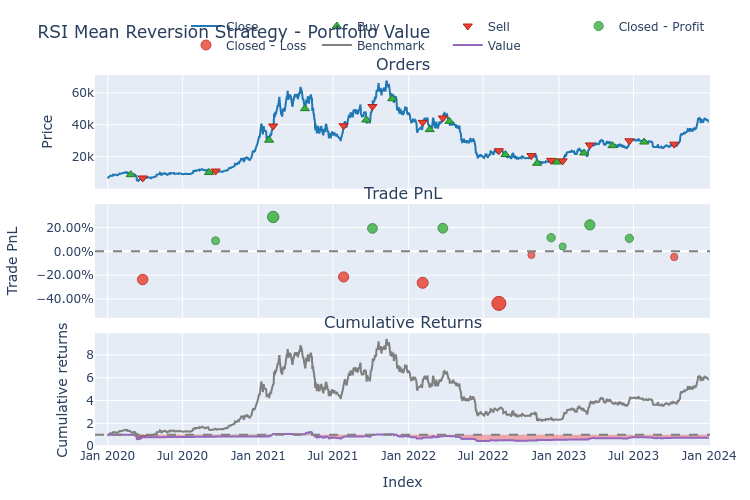

In [16]:
# Plot portfolio value over time
fig = portfolio.plot()
fig.update_layout(title="RSI Mean Reversion Strategy - Portfolio Value", height=500)
fig.show()

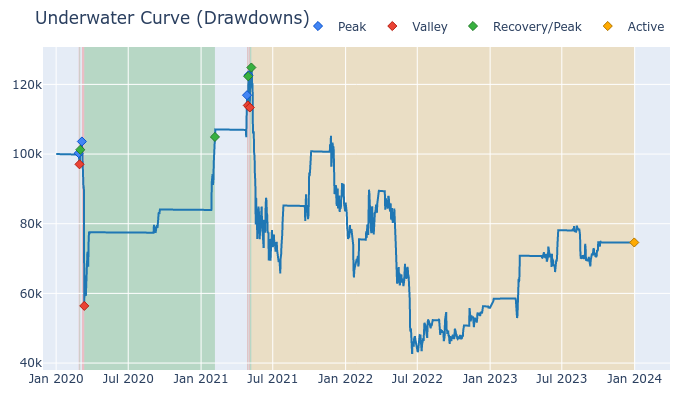

In [17]:
# Plot drawdown
fig_dd = portfolio.drawdowns.plot()
fig_dd.update_layout(title="Underwater Curve (Drawdowns)", height=400)
fig_dd.show()

## 7. Compare to Buy-and-Hold Benchmark

A strategy should beat buy-and-hold to be worthwhile. Let's compare.

In [18]:
# Create buy-and-hold benchmark
bh_portfolio = vbt.Portfolio.from_holding(close=close, init_cash=INITIAL_CASH, fees=FEES, freq="1D")

In [19]:
# Compare key metrics
comparison = pd.DataFrame(
    {
        "RSI Strategy": [
            portfolio.total_return() * 100,
            portfolio.sharpe_ratio(),
            portfolio.max_drawdown() * 100,
            portfolio.trades.count(),
            portfolio.sortino_ratio(),
            portfolio.calmar_ratio(),
        ],
        "Buy & Hold": [
            bh_portfolio.total_return() * 100,
            bh_portfolio.sharpe_ratio(),
            bh_portfolio.max_drawdown() * 100,
            0,  # No trades
            bh_portfolio.sortino_ratio(),
            bh_portfolio.calmar_ratio(),
        ],
    },
    index=[
        "Total Return (%)",
        "Sharpe Ratio",
        "Max Drawdown (%)",
        "Total Trades",
        "Sortino Ratio",
        "Calmar Ratio",
    ],
)

**Strategy vs buy-and-hold comparison** (annualized metrics, daily frequency):

In [20]:
comparison.round(3)

,RSI Strategy,Buy & Hold
Total Return (%),-25.384,487.306
Sharpe Ratio,0.090,1.001
Max Drawdown (%),-65.842,-76.670
Total Trades,14.000,0.000
Sortino Ratio,0.121,1.446
Calmar Ratio,-0.107,0.726


Buy-and-hold dominates on return and Sharpe by a wide margin. The strategy's
only edge is a less severe maximum drawdown (about ten percentage points
shallower) — its exposure management cuts into the worst losses but cannot
compensate for missing the major rallies. This comparison is the minimum
bar any active strategy must clear.

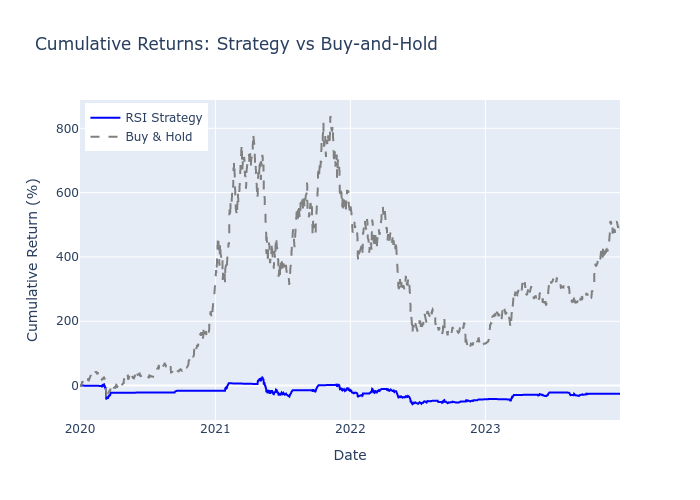

In [21]:
# Plot cumulative returns comparison
fig = go.Figure()

strategy_cum = portfolio.cumulative_returns() * 100
bh_cum = bh_portfolio.cumulative_returns() * 100

fig.add_trace(
    go.Scatter(x=strategy_cum.index, y=strategy_cum, name="RSI Strategy", line=dict(color="blue"))
)

fig.add_trace(
    go.Scatter(x=bh_cum.index, y=bh_cum, name="Buy & Hold", line=dict(color="gray", dash="dash"))
)

fig.update_layout(
    title="Cumulative Returns: Strategy vs Buy-and-Hold",
    xaxis_title="Date",
    yaxis_title="Cumulative Return (%)",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

## 8. Parameter Optimization

VectorBT excels at parameter sweeps. Let's optimize RSI thresholds.

In [22]:
# Define parameter ranges
rsi_windows = [7, 14, 21]
lower_thresholds = [20, 25, 30, 35]
upper_thresholds = [65, 70, 75, 80]

In [23]:
# Run RSI for all window sizes
rsi_multi = vbt.RSI.run(close, window=rsi_windows)

In [24]:
# Create parameter grid for signals
results = []

for window in rsi_windows:
    rsi_vals = vbt.RSI.run(close, window=window).rsi

    for lower in lower_thresholds:
        for upper in upper_thresholds:
            if lower >= upper:
                continue

            entries = rsi_vals < lower
            exits = rsi_vals > upper

            pf = vbt.Portfolio.from_signals(
                close=close,
                entries=entries,
                exits=exits,
                size=0.95,
                size_type="percent",
                init_cash=INITIAL_CASH,
                fees=FEES,
                slippage=SLIPPAGE,
                freq="1D",
            )

            results.append(
                {
                    "window": window,
                    "lower": lower,
                    "upper": upper,
                    "total_return": pf.total_return() * 100,
                    "sharpe": pf.sharpe_ratio(),
                    "max_dd": pf.max_drawdown() * 100,
                    "trades": pf.trades.count(),
                }
            )

In [25]:
# Convert to DataFrame and find best parameters
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("sharpe", ascending=False)

**Top 10 RSI parameter combinations by Sharpe ratio** (in-sample sweep):

In [26]:
results_df.head(10).reset_index(drop=True)

,window,lower,upper,total_return,sharpe,max_dd,trades
0,21,20,75,199.610198,1.238103,-16.265038,3
1,21,25,75,345.964652,1.206924,-33.927454,6
2,21,20,70,124.666094,1.173411,-12.371295,3
3,21,25,65,210.003100,1.158614,-25.318625,7
4,21,25,70,196.915393,1.001140,-33.927454,6
5,7,20,65,233.840122,0.983457,-43.580424,39
6,21,20,65,78.629674,0.925118,-12.371295,3
7,14,20,80,174.465073,0.865330,-33.794698,7
8,7,20,75,197.328965,0.845191,-45.580456,33
9,21,25,80,181.524946,0.805393,-64.139523,4


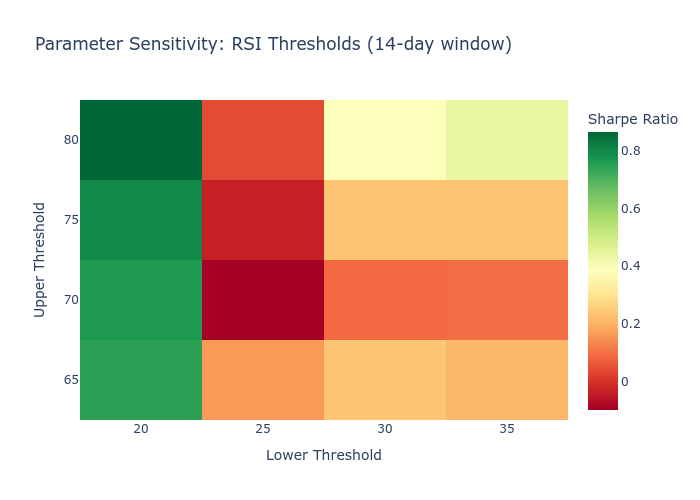

In [27]:
# Visualize parameter sensitivity
fig = go.Figure(
    data=go.Heatmap(
        x=results_df[results_df["window"] == 14]["lower"],
        y=results_df[results_df["window"] == 14]["upper"],
        z=results_df[results_df["window"] == 14]["sharpe"],
        colorscale="RdYlGn",
        colorbar=dict(title="Sharpe Ratio"),
    )
)

fig.update_layout(
    title="Parameter Sensitivity: RSI Thresholds (14-day window)",
    xaxis_title="Lower Threshold",
    yaxis_title="Upper Threshold",
    height=500,
)
fig.show()

The highest in-sample Sharpe in the sweep is over an order of magnitude
above the single-configuration baseline Sharpe printed in §4. That gap is
the magnitude of in-sample optimization, not a forecast of out-of-sample
edge: the parameters were selected after seeing the full dataset. VectorBT's
speed makes such sweeps trivial to run, which makes overfitting risk
correspondingly higher. The Deflated Sharpe Ratio (NB 12) addresses exactly
this problem.

## 9. Evaluate with ml4t-diagnostic

For comprehensive portfolio analysis, we use ml4t-diagnostic's PortfolioAnalysis.

In [28]:
# Get daily returns
strategy_returns = portfolio.returns().values
benchmark_returns = bh_portfolio.returns().values

# Create analysis object
analysis = PortfolioAnalysis(
    returns=strategy_returns,
    benchmark=benchmark_returns,
    dates=portfolio.returns().index,
    periods_per_year=365,  # Crypto trades 365 days
)

# Compute comprehensive metrics
metrics = analysis.compute_summary_stats()

**ml4t-diagnostic comprehensive portfolio evaluation:**

In [29]:
print(metrics.summary())

Portfolio Performance Summary

Returns
------------------------------
  Total Return:           -25.38%
  Annual Return:           -7.05%
  Annual Volatility:       46.67%

Risk-Adjusted Returns
------------------------------
  Sharpe Ratio:             0.090
  Sortino Ratio:            0.057
  Calmar Ratio:            -0.107
  Omega Ratio:              1.023
  Tail Ratio:               1.019

Risk Metrics
------------------------------
  Max Drawdown:           -65.84%
  VaR (95%):               -3.13%
  CVaR (95%):              -6.25%

Distribution
------------------------------
  Skewness:                -2.242
  Kurtosis:                46.347
  Stability (R²):           0.261

Win/Loss
------------------------------
  Win Rate:                21.63%
  Profit Factor:             1.02
  Avg Win:                  2.37%
  Avg Loss:                -2.23%

Benchmark Comparison
------------------------------
  Alpha (annual):         -30.04%
  Beta:                     0.503
  Informatio

## See Also

**ml4t-backtest Implementation**: See [`04_single_asset_ml4t_backtest`](04_single_asset_ml4t_backtest.ipynb) for the same
strategy implemented with ml4t-backtest's event-driven engine. The main difference
is not capability — VectorBT also supports stops, fills, and risk rules — but
representation: ml4t-backtest expresses strategy logic as a Python class with
explicit state, which mirrors how live trading code is typically structured.

## Key Takeaways

1. **VectorBT API**: `Portfolio.from_signals()` is the core function for signal-based backtests

2. **Signal Generation**: Entry/exit signals are boolean arrays - simple and intuitive

3. **Parameter Optimization**: Vectorized operations enable fast parameter sweeps

4. **Transaction Costs**: Always include fees and slippage for realistic results

5. **Benchmarking**: Compare to buy-and-hold to validate strategy edge

## Next Steps

- **06_framework_parity**: Compare vectorized and event-driven implementations
- **08_signal_method_comparison**: Compare signal conversion methods